Trying Neural Networks for Families in the Wild

In [1]:
!wget https://raw.githubusercontent.com/Zhangxm520/RFIW2021/refs/heads/master/Track1/sample0/val.txt

--2025-01-20 16:27:45--  https://raw.githubusercontent.com/Zhangxm520/RFIW2021/refs/heads/master/Track1/sample0/val.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10999077 (10M) [text/plain]
Saving to: ‘val.txt’

val.txt             100%[===================>]  10.49M  68.9MB/s    in 0.2s    

2025-01-20 16:27:45 (68.9 MB/s) - ‘val.txt’ saved [10999077/10999077]



In [2]:
!wget https://raw.githubusercontent.com/Zhangxm520/RFIW2021/refs/heads/master/Track1/sample0/test.txt

--2025-01-20 16:27:47--  https://raw.githubusercontent.com/Zhangxm520/RFIW2021/refs/heads/master/Track1/sample0/test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2720118 (2.6M) [text/plain]
Saving to: ‘test.txt’

test.txt            100%[===================>]   2.59M  --.-KB/s    in 0.05s   

2025-01-20 16:27:48 (50.0 MB/s) - ‘test.txt’ saved [2720118/2720118]



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pickle

with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/FIW_buffalo_sc_faces_info.pkl", "rb") as f:
  buffalo_sc_embeddings = pickle.load(f)

In [5]:
import pandas as pd

val_df = pd.read_csv('val.txt', sep=' ', header=None, index_col=0)
val_df

,1,2,3,4
0,,,,
0,Validation/val-faces/F0007/MID1/P00075_face0.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,1
1,Validation/val-faces/F0007/MID1/P00078_face3.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,1
2,Validation/val-faces/F0007/MID1/P11275_face2.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,1
3,Validation/val-faces/F0007/MID1/P00077_face12.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,1
4,Validation/val-faces/F0007/MID1/P00082_face1.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,1
...,...,...,...,...
100569,Validation/val-faces/F0769/MID5/P08125_face1.jpg,Validation/val-faces/F0490/MID2/P05149_face1.jpg,gmgd,0
100570,Validation/val-faces/F0873/MID10/P09222_face1.jpg,Validation/val-faces/F0513/MID4/P10961_face2.jpg,gmgd,0
100571,Validation/val-faces/F0333/MID4/P03525_face0.jpg,Validation/val-faces/F0443/MID5/P04676_face2.jpg,gmgd,0


In [6]:
val_df = val_df.sample(frac=0.1)
val_df

,1,2,3,4
0,,,,
48001,Validation/val-faces/F0990/MID3/P06404_face1.jpg,Validation/val-faces/F0990/MID7/P10437_face1.jpg,gfgd,1
43748,Validation/val-faces/F0931/MID4/P09824_face2.jpg,Validation/val-faces/F0931/MID3/P09819_face1.jpg,fd,1
58412,Validation/val-faces/F0468/MID1/P04940_face0.jpg,Validation/val-faces/F0283/MID5/P03018_face0.jpg,bb,0
82996,Validation/val-faces/F0431/MID2/P04535_face1.jpg,Validation/val-faces/F0481/MID4/P05074_face1.jpg,md,0
99980,Validation/val-faces/F0990/MID10/P10431_face3.jpg,Validation/val-faces/F0199/MID3/P02136_face2.jpg,gmgd,0
...,...,...,...,...
55141,Validation/val-faces/F0785/MID7/P08287_face7.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,0
14432,Validation/val-faces/F0360/MID2/P12297_face1.jpg,Validation/val-faces/F0360/MID3/P12310_face0.jpg,fs,1
4727,Validation/val-faces/F0147/MID1/P01580_face4.jpg,Validation/val-faces/F0147/MID4/P01580_face1.jpg,sibs,1


In [7]:
test_df = pd.read_csv('test.txt', sep=' ', header=None, index_col=0)
test_df

,1,2,3,4
0,,,,
0,Test/test-faces/face3118.jpg,Test/test-faces/face322.jpg,bb,1
1,Test/test-faces/face1058.jpg,Test/test-faces/face322.jpg,bb,1
2,Test/test-faces/face1859.jpg,Test/test-faces/face2895.jpg,bb,1
3,Test/test-faces/face4234.jpg,Test/test-faces/face2895.jpg,bb,1
4,Test/test-faces/face4234.jpg,Test/test-faces/face322.jpg,bb,1
...,...,...,...,...
39738,Test/test-faces/face4875.jpg,Test/test-faces/face4100.jpg,ss,0
39739,Test/test-faces/face4875.jpg,Test/test-faces/face1110.jpg,ss,0
39740,Test/test-faces/face2825.jpg,Test/test-faces/face5216.jpg,ss,0


In [8]:
prefix = "/content/dataset/"
val_df["non_empty"] = val_df.apply(lambda x: buffalo_sc_embeddings[prefix + x[1]] is not None and buffalo_sc_embeddings[prefix + x[2]] is not None, axis=1)
val_df_non_empty = val_df[val_df["non_empty"]]
val_df_non_empty

,1,2,3,4,non_empty
0,,,,,
48001,Validation/val-faces/F0990/MID3/P06404_face1.jpg,Validation/val-faces/F0990/MID7/P10437_face1.jpg,gfgd,1,True
43748,Validation/val-faces/F0931/MID4/P09824_face2.jpg,Validation/val-faces/F0931/MID3/P09819_face1.jpg,fd,1,True
58412,Validation/val-faces/F0468/MID1/P04940_face0.jpg,Validation/val-faces/F0283/MID5/P03018_face0.jpg,bb,0,True
82996,Validation/val-faces/F0431/MID2/P04535_face1.jpg,Validation/val-faces/F0481/MID4/P05074_face1.jpg,md,0,True
99980,Validation/val-faces/F0990/MID10/P10431_face3.jpg,Validation/val-faces/F0199/MID3/P02136_face2.jpg,gmgd,0,True
...,...,...,...,...,...
55141,Validation/val-faces/F0785/MID7/P08287_face7.jpg,Validation/val-faces/F0007/MID9/P00079_face3.jpg,sibs,0,True
14432,Validation/val-faces/F0360/MID2/P12297_face1.jpg,Validation/val-faces/F0360/MID3/P12310_face0.jpg,fs,1,True
4727,Validation/val-faces/F0147/MID1/P01580_face4.jpg,Validation/val-faces/F0147/MID4/P01580_face1.jpg,sibs,1,True


In [9]:
test_df["non_empty"] = test_df.apply(lambda x: buffalo_sc_embeddings[prefix + x[1]] is not None and buffalo_sc_embeddings[prefix + x[2]] is not None, axis=1)
test_df_non_empty = test_df[test_df["non_empty"]]
test_df_non_empty

,1,2,3,4,non_empty
0,,,,,
0,Test/test-faces/face3118.jpg,Test/test-faces/face322.jpg,bb,1,True
1,Test/test-faces/face1058.jpg,Test/test-faces/face322.jpg,bb,1,True
2,Test/test-faces/face1859.jpg,Test/test-faces/face2895.jpg,bb,1,True
3,Test/test-faces/face4234.jpg,Test/test-faces/face2895.jpg,bb,1,True
4,Test/test-faces/face4234.jpg,Test/test-faces/face322.jpg,bb,1,True
...,...,...,...,...,...
39738,Test/test-faces/face4875.jpg,Test/test-faces/face4100.jpg,ss,0,True
39739,Test/test-faces/face4875.jpg,Test/test-faces/face1110.jpg,ss,0,True
39740,Test/test-faces/face2825.jpg,Test/test-faces/face5216.jpg,ss,0,True


In [10]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm

from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [11]:

def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


In [12]:
train_df = pd.read_csv("train_pairs.csv")
train_df

,image1,image2,kinship
0,Train/train-faces/F0523/MID1/P05497_face1.jpg,Train/train-faces/F0523/MID3/P05501_face0.jpg,1
1,Train/train-faces/F0523/MID1/P05497_face1.jpg,Train/train-faces/F0523/MID3/P05499_face1.jpg,1
2,Train/train-faces/F0523/MID1/P05500_face0.jpg,Train/train-faces/F0523/MID3/P05501_face0.jpg,1
3,Train/train-faces/F0523/MID1/P05500_face0.jpg,Train/train-faces/F0523/MID3/P05499_face1.jpg,1
4,Train/train-faces/F0523/MID1/P05499_face6.jpg,Train/train-faces/F0523/MID3/P05501_face0.jpg,1
...,...,...,...
538577,Train/train-faces/F0411/MID3/P04330_face0.jpg,Train/train-faces/F0601/MID1/P06300_face20.jpg,0
538578,Train/train-faces/F0601/MID3/P11903_face0.jpg,Train/train-faces/F0845/MID3/P08924_face0.jpg,0
538579,Train/train-faces/F0157/MID4/P01679_face3.jpg,Train/train-faces/F0466/MID5/P04921_face2.jpg,0
538580,Train/train-faces/F0073/MID1/P00756_face1.jpg,Train/train-faces/F0601/MID10/P06392_face13.jpg,0


In [13]:
train_df = train_df.sample(frac=0.1).reset_index(drop=True)
train_df

,image1,image2,kinship
0,Train/train-faces/F0552/MID1/P05794_face2.jpg,Train/train-faces/F0552/MID9/P05789_face0.jpg,1
1,Train/train-faces/F0326/MID5/P03456_face4.jpg,Train/train-faces/F0631/MID5/P06619_face0.jpg,0
2,Train/train-faces/F0081/MID1/P00834_face2.jpg,Train/train-faces/F0131/MID2/P01368_face1.jpg,0
3,Train/train-faces/F0466/MID4/P04919_face0.jpg,Train/train-faces/F0922/MID4/P09732_face1.jpg,0
4,Train/train-faces/F0297/MID1/P03160_face0.jpg,Train/train-faces/F0297/MID3/P03165_face3.jpg,1
...,...,...,...
53853,Train/train-faces/F0860/MID1/P09091_face1.jpg,Train/train-faces/F0860/MID4/P09093_face0.jpg,1
53854,Train/train-faces/F0601/MID1/P11952_face12.jpg,Train/train-faces/F0601/MID7/P06291_face2.jpg,1
53855,Train/train-faces/F0101/MID2/P01042_face5.jpg,Train/train-faces/F0646/MID2/P06809_face1.jpg,0
53856,Train/train-faces/F0601/MID2/P11880_face1.jpg,Train/train-faces/F0601/MID7/P06285_face1.jpg,1


In [14]:
train_df["non_empty"] = train_df.apply(lambda x: buffalo_sc_embeddings[prefix + x["image1"]] is not None and buffalo_sc_embeddings[prefix + x["image2"]] is not None, axis=1)
train_df_non_empty = train_df[train_df["non_empty"]]
train_df_non_empty

,image1,image2,kinship,non_empty
0,Train/train-faces/F0552/MID1/P05794_face2.jpg,Train/train-faces/F0552/MID9/P05789_face0.jpg,1,True
1,Train/train-faces/F0326/MID5/P03456_face4.jpg,Train/train-faces/F0631/MID5/P06619_face0.jpg,0,True
2,Train/train-faces/F0081/MID1/P00834_face2.jpg,Train/train-faces/F0131/MID2/P01368_face1.jpg,0,True
3,Train/train-faces/F0466/MID4/P04919_face0.jpg,Train/train-faces/F0922/MID4/P09732_face1.jpg,0,True
4,Train/train-faces/F0297/MID1/P03160_face0.jpg,Train/train-faces/F0297/MID3/P03165_face3.jpg,1,True
...,...,...,...,...
53853,Train/train-faces/F0860/MID1/P09091_face1.jpg,Train/train-faces/F0860/MID4/P09093_face0.jpg,1,True
53854,Train/train-faces/F0601/MID1/P11952_face12.jpg,Train/train-faces/F0601/MID7/P06291_face2.jpg,1,True
53855,Train/train-faces/F0101/MID2/P01042_face5.jpg,Train/train-faces/F0646/MID2/P06809_face1.jpg,0,True
53856,Train/train-faces/F0601/MID2/P11880_face1.jpg,Train/train-faces/F0601/MID7/P06285_face1.jpg,1,True


In [57]:
import numpy as np
from scipy.spatial.distance import cosine

image1_arrays = [buffalo_sc_embeddings[prefix + x]["embedding"].reshape(1, -1) for x in train_df_non_empty["image1"]]
image2_arrays = [buffalo_sc_embeddings[prefix + x]["embedding"].reshape(1, -1) for x in train_df_non_empty["image2"]]
X_train = pd.DataFrame((np.concatenate(image1_arrays) - np.concatenate(image2_arrays))**2)
X_train["cosine_similarity"] = (np.concatenate(image1_arrays) * np.concatenate(image2_arrays)).sum(axis=1) / np.linalg.norm(np.concatenate(image1_arrays), axis=1)
X_train

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,cosine_similarity
0,6.171390,0.019615,2.745257,5.292160,0.003673,0.070928,2.883862,0.094720,0.499837,0.000766,...,0.224810,4.811704,0.646308,0.413881,0.087283,2.424164,0.418074,4.130356,3.548337,3.511345
1,1.924080,0.000090,0.115054,3.418525,0.232204,0.379829,0.180763,1.523040,0.007886,6.576886,...,2.100873,2.833494,0.534512,0.000171,0.007140,0.021756,0.383552,1.168781,7.241302,1.315952
2,0.141300,10.123347,3.568646,0.752136,0.080519,0.919568,8.284029,0.412658,0.055669,9.974120,...,1.535818,8.393570,0.500282,1.102804,0.146228,1.426576,0.163031,1.716526,0.378564,-0.728370
3,2.115122,0.023152,0.322101,1.422507,0.363108,0.080229,3.991323,2.124396,2.957616,3.155524,...,3.534453,0.476364,0.000411,6.346807,0.111888,3.237841,6.001710,0.341285,1.560339,-1.444095
4,5.134102,0.141225,0.013503,0.593931,0.452140,1.532942,1.736917,0.946974,1.154417,3.639232,...,0.643624,2.377244,0.393765,0.020101,0.760191,0.403610,0.113499,1.817976,0.160771,1.790480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53486,0.043692,3.724453,0.239915,3.032246,6.591137,3.007851,1.813661,0.649955,0.285118,1.232404,...,0.344420,0.011823,1.335013,0.295518,24.903624,3.792851,2.358396,3.483361,0.071770,0.042849
53487,3.694785,1.767327,0.587823,0.308515,0.953722,2.059317,0.101978,4.703100,5.530739,0.636620,...,1.779706,1.146129,0.614956,0.000259,2.325594,0.102305,4.780816,6.538008,2.345822,3.371650
53488,17.961233,0.030485,0.963575,0.871917,1.585645,2.993516,0.739537,0.105482,1.011692,0.135655,...,1.479874,1.100597,0.241913,6.169048,0.023433,0.305964,2.085799,6.680286,0.150302,4.910962
53489,6.301018,0.229242,1.637659,3.142445,0.232141,2.306195,0.040032,0.135470,2.426973,0.034168,...,3.439584,0.003973,1.965958,1.691036,0.052154,0.000050,0.156418,11.988710,0.386537,1.565925


In [16]:
y_train = train_df_non_empty["kinship"]
y_train

,kinship
0,1
1,0
2,0
3,0
4,1
...,...
53853,1
53854,1
53855,0
53856,1


In [58]:
image1_arrays = [buffalo_sc_embeddings[prefix + x]["embedding"].reshape(1, -1) for x in val_df_non_empty[1]]
image2_arrays = [buffalo_sc_embeddings[prefix + x]["embedding"].reshape(1, -1) for x in val_df_non_empty[2]]
X_val = pd.DataFrame((np.concatenate(image1_arrays) - np.concatenate(image2_arrays)) ** 2)
X_val["cosine_similarity"] = (np.concatenate(image1_arrays) * np.concatenate(image2_arrays)).sum(axis=1) / np.linalg.norm(np.concatenate(image1_arrays), axis=1)
y_val = val_df_non_empty[4]

In [59]:
image1_arrays = [buffalo_sc_embeddings[prefix + x]["embedding"].reshape(1, -1) for x in test_df_non_empty[1]]
image2_arrays = [buffalo_sc_embeddings[prefix + x]["embedding"].reshape(1, -1) for x in test_df_non_empty[2]]
X_test = pd.DataFrame((np.concatenate(image1_arrays) - np.concatenate(image2_arrays)) ** 2)
X_test["cosine_similarity"] = (np.concatenate(image1_arrays) * np.concatenate(image2_arrays)).sum(axis=1) / np.linalg.norm(np.concatenate(image1_arrays), axis=1)
y_test = test_df_non_empty[4]

2. Подготовьте данные к обучению - **1 балл**
    - Разделите датасет на обучающую, валидационную и тестовую выборки со стратификацией в пропорции 60/20/20. В качестве целевой переменной используйте столбец `Class` - бинарный столбец (0 - нейтральное ПО, 1 - вредоносное ПО).
    - **hint**: для ускорения сходимости и стабилизации обучения можно стандартизировать входные признаки, например, с помощью `StandardScaler`
    - Создайте объекты для работы с данными в PyTorch - `Dataset` и `DataLoader` для обучающей, валидационной и тестовой выборок. Выберите оптимальный, на ваш взгляд, `batch_size`.

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train.columns = X_train.columns.astype(str)
X_val.columns = X_val.columns.astype(str)
X_test.columns = X_test.columns.astype(str)
columns = X_train.columns
X_train[columns] = scaler.fit_transform(X_train[columns])
X_val[columns] = scaler.transform(X_val[columns])
X_test[columns] = scaler.transform(X_test[columns])

In [66]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(X.values)
        self.y = torch.from_numpy(y.values).reshape(-1, 1).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return (self.X[index], self.y[index])


In [67]:
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)

In [68]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

(Возьмем batch_size=32 как один из часто использующихся)

3. Реализуйте класс бейзлайновой нейросетевой модели (MLP) для решения задачи - **2 балла**
    - Определите оптимальное количество `Linear` слоев в структуре и их размерности.
    - Подберите оптимальные для задачи функции активации - `ReLU`, `Sigmoid`, `Tanh`, `LeakyReLU`...
    - Реализуйте логику прохождения данных по сети в методе `forward`
    - Cоздайте объект модели, реализуйте перевод модели на gpu

In [86]:
class BestTorchModel(nn.Module):
    def __init__(self, num_labels, input_size):
        super(BestTorchModel, self).__init__()

        layers = []
        layers.append(nn.Linear(input_size, 512))
        layers.append(nn.BatchNorm1d(512))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.1))

        layers.append(nn.Linear(512, 256))
        layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.1))

        layers.append(nn.Linear(256, 128))
        layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.1))

        layers.append(nn.Linear(128, 64))
        layers.append(nn.BatchNorm1d(64))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.1))

        layers.append(nn.Linear(64, num_labels))




        self.layers = nn.Sequential(*layers) # https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Начнем с модели с 2 скрытыми слоями по 16 нейронов, с ReLU в качестве функции активации.

In [72]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1])
model.to(device)

BestTorchModel(
  (layers): Sequential(
    (0): Linear(in_features=513, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)

4. Напишите код цикла обучения - train-loop и валидации - eval-loop. В процессе обучения сохраняйте и визуализируйте на графике динамику функции потерь на тренировочной и валидационной выборках - **1 балл**

In [73]:
def train_model(model, num_epochs=100, eval_freq=10):
  train_loss_history, eval_loss_history = [], []
  train_accuracy_history, eval_accuracy_history = [], []
  global_step = 0

  models = []
  eval_accuracy_history_epochs, eval_loss_history_epochs = [], [] #для выбора количества эпох будем еще сохранять значения после каждой эпохи

  model.train()
  for epoch in tqdm(range(num_epochs)):

      for batch_X, target in train_dataloader:
        optimizer.zero_grad()
        log_probs = model(batch_X.to(device))
        loss = loss_function(log_probs, target.to(device))
        loss.backward()
        optimizer.step()

        preds = (log_probs >= 0.5).int().cpu().tolist()
        accuracy = accuracy_score(preds, target.cpu().numpy().tolist())

        train_loss_history.append((global_step, loss.item()))
        train_accuracy_history.append((global_step, accuracy))

        if global_step % eval_freq == 0:
              val_loss, val_accuracy = evaluate(model)
              eval_loss_history.append((global_step, val_loss))
              eval_accuracy_history.append((global_step, val_accuracy))
              model.train()

        if global_step % 250 == 0:
              clear_output(True)

              plt.figure(figsize=(15, 5))

              plt.subplot(121)
              plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
              if len(eval_loss_history):
                  plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
              plt.legend()

              plt.subplot(122)
              plt.plot(*zip(*train_accuracy_history), alpha=0.5, label='train_accuracy')
              if len(eval_accuracy_history):
                  plt.plot(*zip(*eval_accuracy_history), color='red', label='eval_accuracy')
              plt.legend()
              plt.show()
        global_step += 1

      models.append(model)
      eval_loss_history_epochs.append(val_loss)
      eval_accuracy_history_epochs.append(val_accuracy)

  return models, eval_loss_history_epochs, eval_accuracy_history_epochs

In [74]:

@torch.no_grad()
def evaluate(model, mode='eval'):
    model.eval()

    dataloader = val_dataloader if mode == 'eval' else test_dataloader

    loss_epoch = 0.
    num_epoch = 0.
    preds_list = []
    targets_list = []

    for batch_X, target in dataloader:
      log_probs = model(batch_X.to(device))
      loss = loss_function(log_probs, target.to(device))
      num = log_probs.shape[0]
      loss_epoch += loss.item() * num
      num_epoch += num

      preds_list += (log_probs >= 0.5).int().cpu().tolist()
      targets_list += target.cpu().numpy().tolist()

    accuracy = accuracy_score(preds_list, targets_list)

    return loss_epoch / num_epoch, accuracy


5. Обучите модель и проверьте ее качество - **1 балл**
    - Выберите оптимизатор, в качестве функции потерь используйте `nn.BCELoss`
    - Запустите обучение, постарайтесь подобрать оптимальные скорость обучения и количество эпох, ориентируясь на динамику функции потерь на train/val
    - Измерьте качество лучшей модели на тестовой выборке, постройте отчет о классификации - `classification_report`

In [91]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1])
model.to(device)

BestTorchModel(
  (layers): Sequential(
    (0): Linear(in_features=513, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [92]:
loss_function = nn.BCELoss()

Начнем с SGD с шагом по умолчанию

In [93]:
optimizer = optim.AdamW(model.parameters(), lr=0.1)

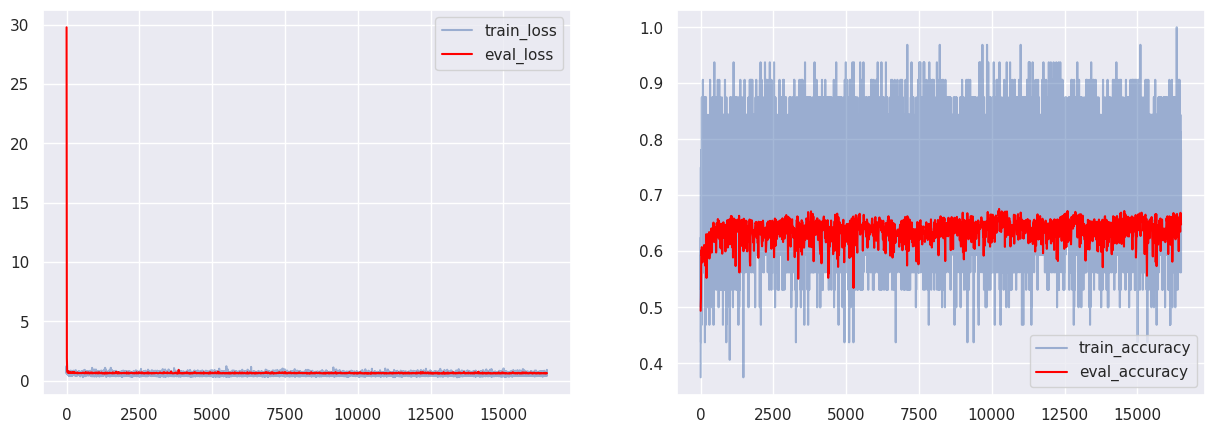

In [94]:
models, eval_loss_history_epochs, eval_accuracy_history_epochs = train_model(model, num_epochs=10)

Мало учится, увеличим шаг

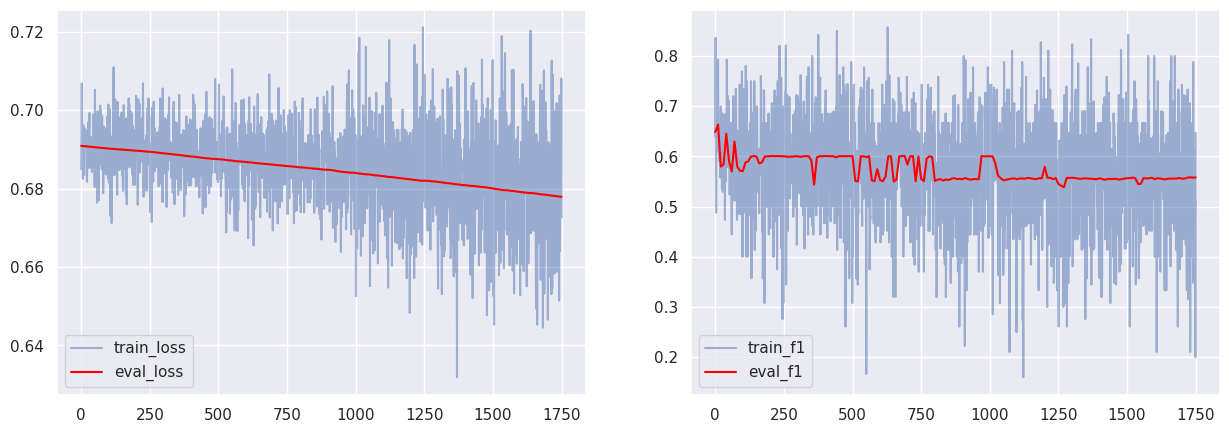

In [ ]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=10)

попробуем еще увеличить

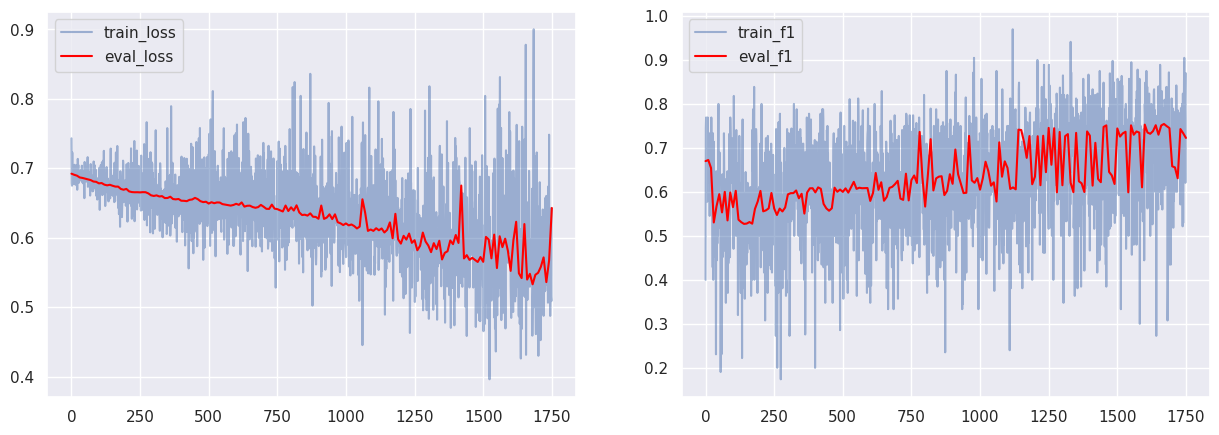

In [ ]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=10)

получается лучше, но ошибки начинают сильно прыгать, а при уменьшении шага качество ухудшается:

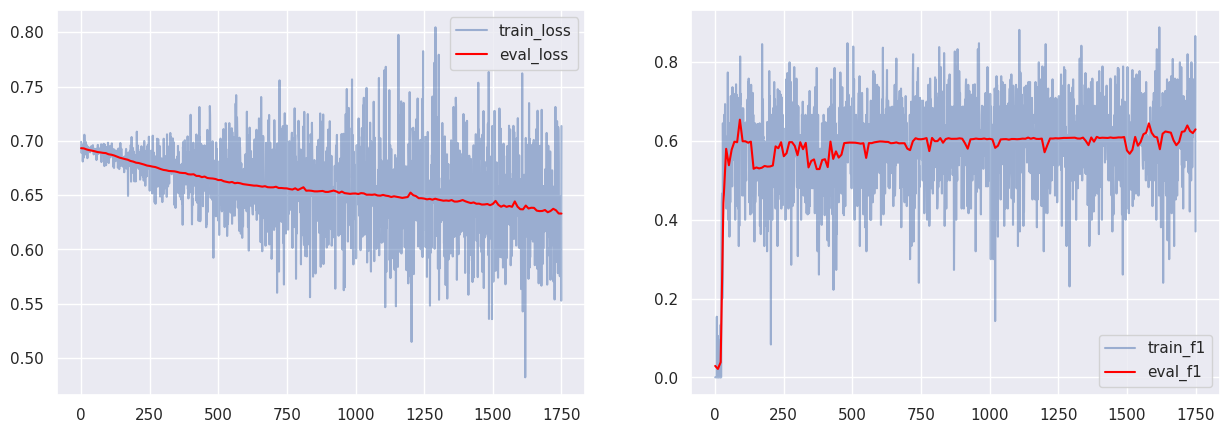

In [ ]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.05)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=10)

Поэтому зафиксируем шаг 0.1 и добавим момент

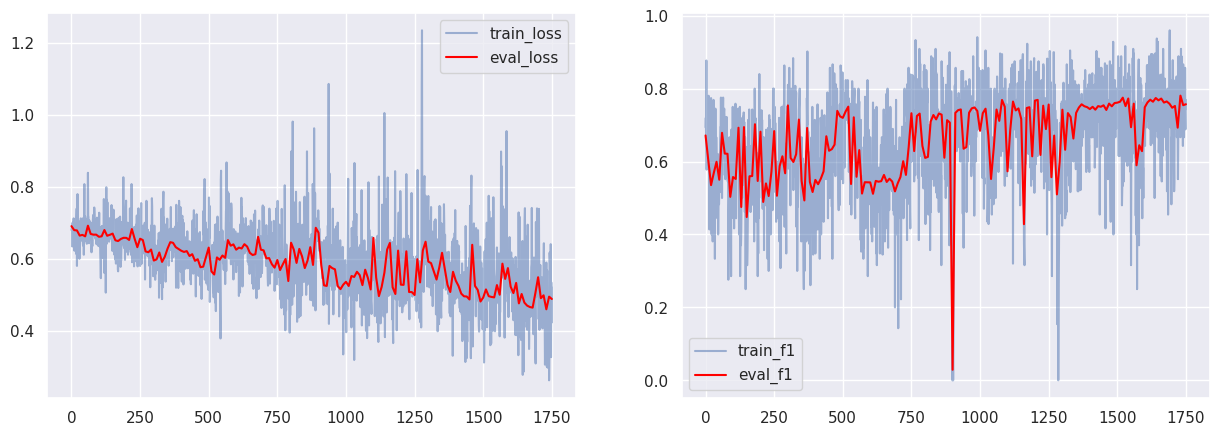

In [ ]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=10)

Получилось лучше, но теперь немного уменьшим момент

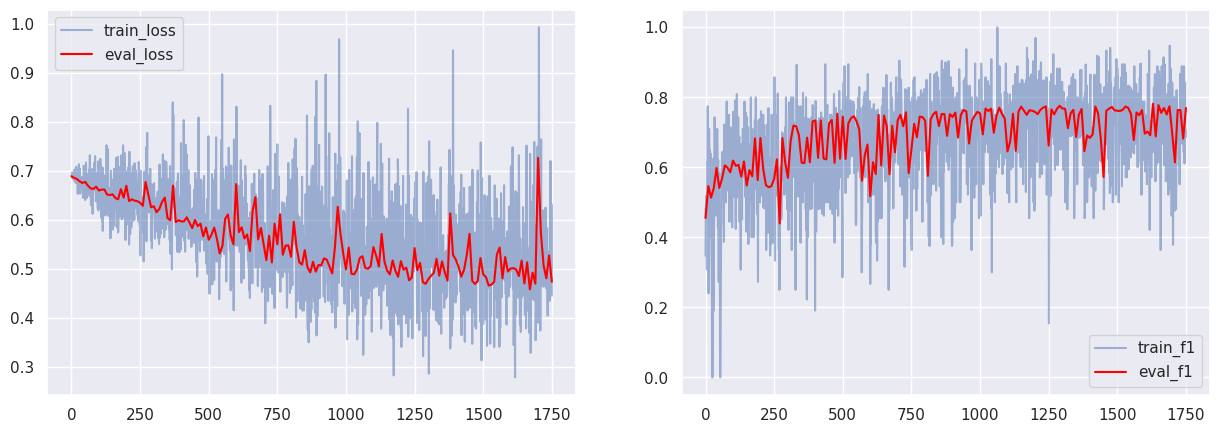

In [ ]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=10)

Возьмем эти параметры, и будем подбирать количество эпох

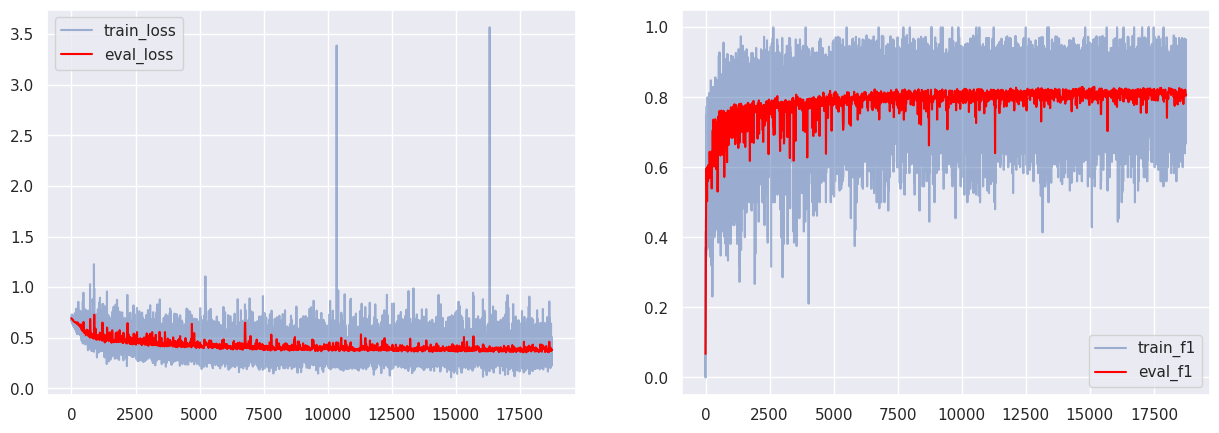

In [ ]:
model = BestTorchModel(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=100)

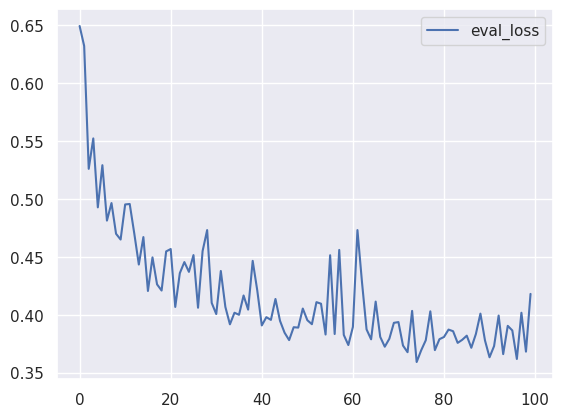

In [ ]:
plt.plot(eval_loss_history_epochs, label='eval_loss')
plt.legend()
plt.show()

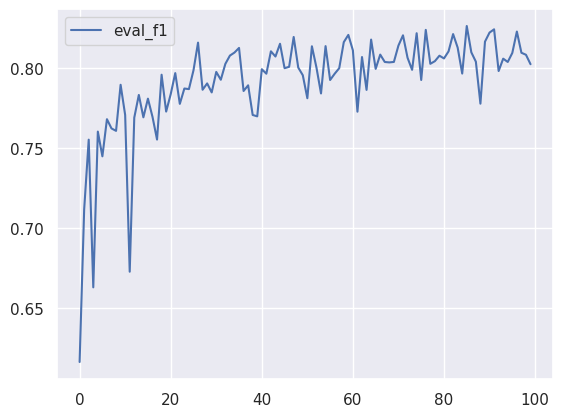

In [ ]:
plt.plot(eval_f1_history_epochs, label='eval_f1')
plt.legend()
plt.show()

Возьмем 70 эпох, далее нет сильного улучшения

посмотрим качество на тестовой выборке:

In [ ]:
best_model = models[70 - 1]

In [ ]:
test_preds = (best_model(torch.Tensor(X_test.values).to(device)) >= 0.5).int().cpu().tolist()

In [ ]:
print(classification_report(test_preds, y_test.values.tolist()))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1218
           1       0.71      0.92      0.80       782

    accuracy                           0.82      2000
   macro avg       0.82      0.84      0.82      2000
weighted avg       0.85      0.82      0.82      2000



В качестве основной метрики зафиксируем заначение f1 ошибки, оно равно 0.8

6. Улучшите архитектуру модели из пункта 3 и добейтесь увеличения качества - **3 балла**
    - Попробуйте добавить слои `BatchNorm1d` и `Dropout` - поэкспериментируйте с их "расположением" в сети, напишите свои выводы о целесообразности их добавления в модель, оптимальном расположении, влиянии на качество/сходимость обучения. При использовании слоя `Dropout` - определите экспериментально или обоснуйте теоретически оптимальное значение параметра `p`.
    - Обучите улучшенную модель и проверьте ее качество (при необходимости измените гиперпараметры обучения - `batch_size`, скорость обучения и количество эпох, ориентируясь на динамику функции потерь на train/val и архитектуру модели)

Сначала добавим нормализацию батчей. Как известно, ее помещают перед функциями активации

In [ ]:
class BestTorchModel_BN(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU):
        super(BestTorchModel_BN, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

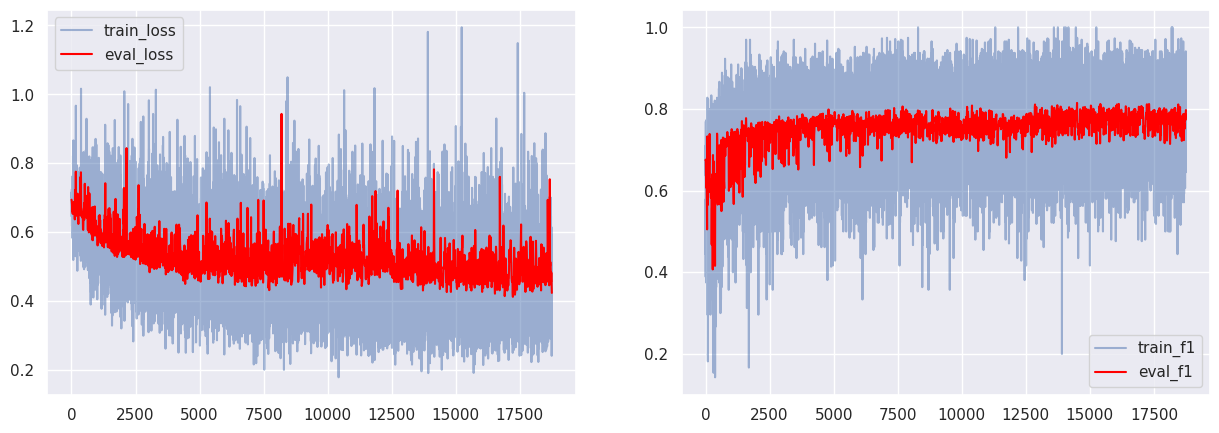

In [ ]:
model = BestTorchModel_BN(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=100)

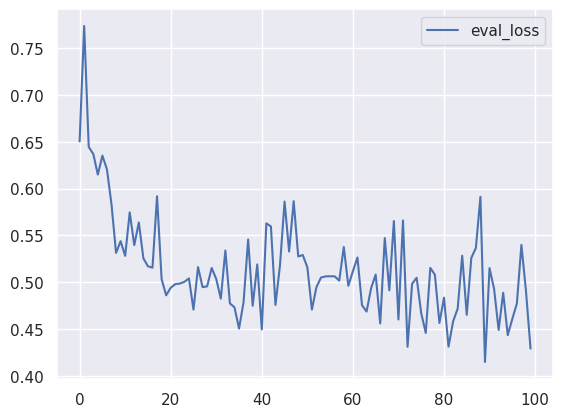

In [ ]:
plt.plot(eval_loss_history_epochs, label='eval_loss')
plt.legend()
plt.show()

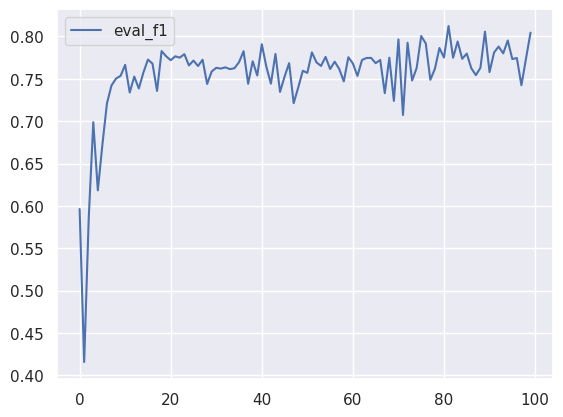

In [ ]:
plt.plot(eval_f1_history_epochs, label='eval_f1')
plt.legend()
plt.show()

In [ ]:
best_model = models[70 - 1]
test_preds = (best_model(torch.Tensor(X_test.values).to(device)) >= 0.5).int().cpu().tolist()
print(classification_report(test_preds, y_test.values.tolist()))

              precision    recall  f1-score   support

           0       0.78      0.75      0.77      1020
           1       0.75      0.78      0.77       980

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



Получилось немного хуже. Размер батча и так относительно большой, так что попробуем переставить BN после функций активации, тем более что у нас ReLU

In [ ]:
class BestTorchModel_BN_after_activation(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU):
        super(BestTorchModel_BN_after_activation, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation())
            layers.append(nn.BatchNorm1d(hidden_size))

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

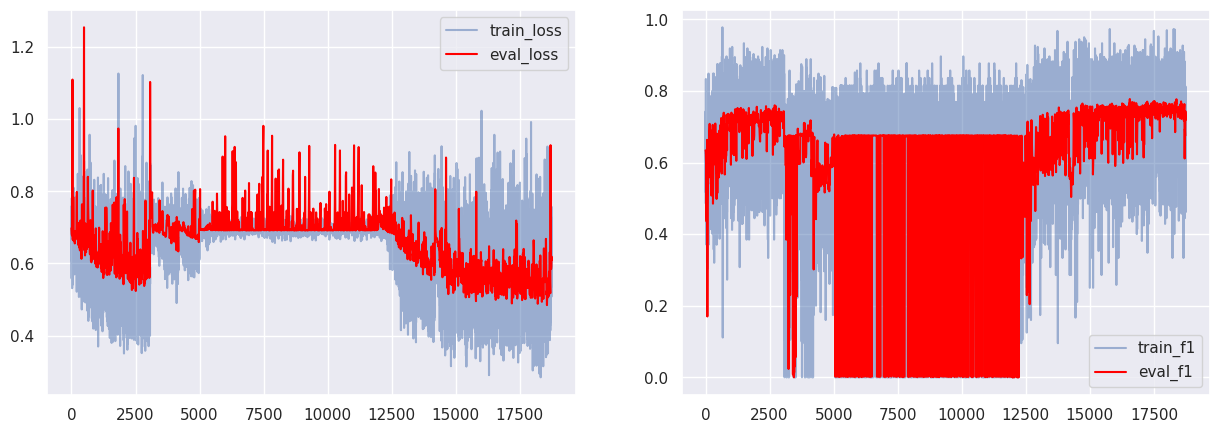

In [ ]:
model = BestTorchModel_BN_after_activation(num_labels=1, input_size=X_train.shape[1], hidden_size=16, n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=100)

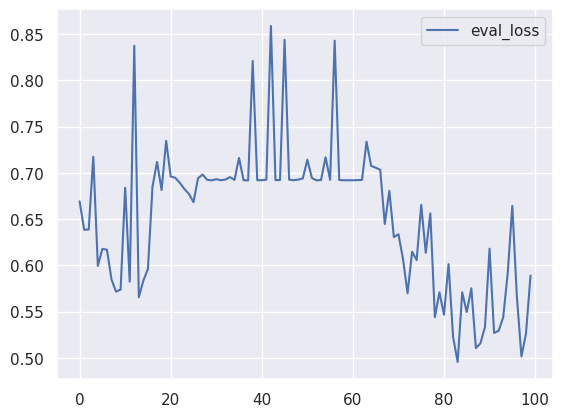

In [ ]:
plt.plot(eval_loss_history_epochs, label='eval_loss')
plt.legend()
plt.show()

Получилось странно, отклоним эту идею.

Не будем добавлять нормализацию батчей, попробуем дропаут

In [ ]:

class BestTorchModel_Dropout(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, p_list, n_linear_layers=2, activation=nn.ReLU):
        super(BestTorchModel_Dropout, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.Dropout(p=p_list[0]), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Dropout(p=p_list[i+1]))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

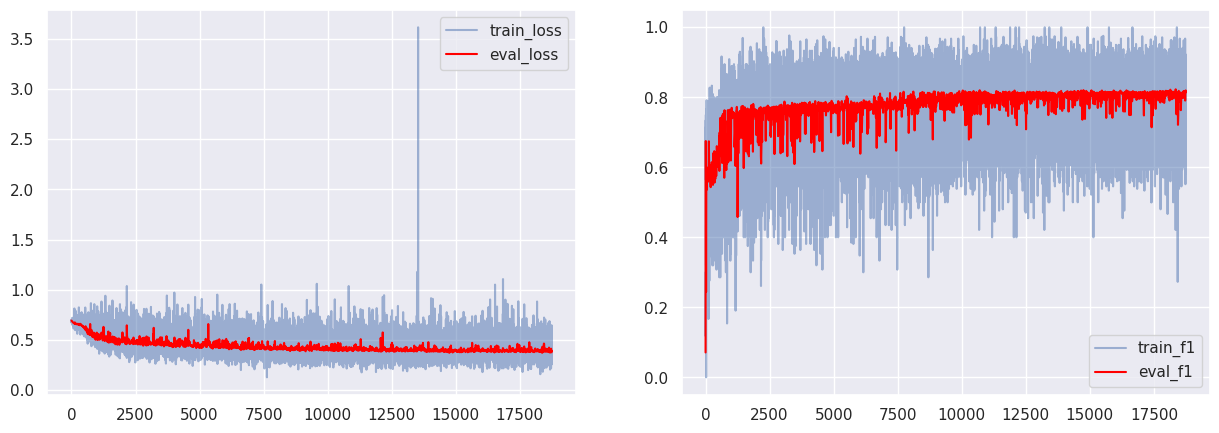

In [ ]:
model = BestTorchModel_Dropout(num_labels=1, input_size=X_train.shape[1], hidden_size=16, p_list=[0.1, 0.1], n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=100)

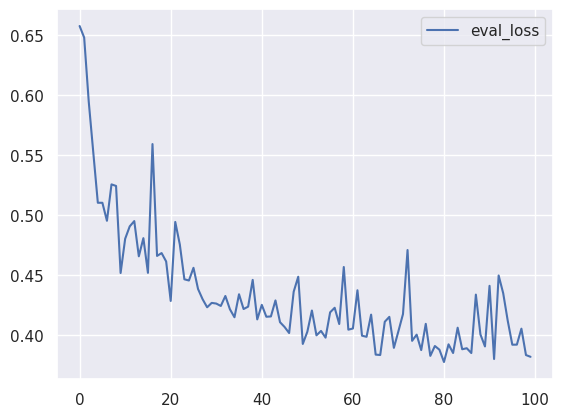

In [ ]:
plt.plot(eval_loss_history_epochs, label='eval_loss')
plt.legend()
plt.show()

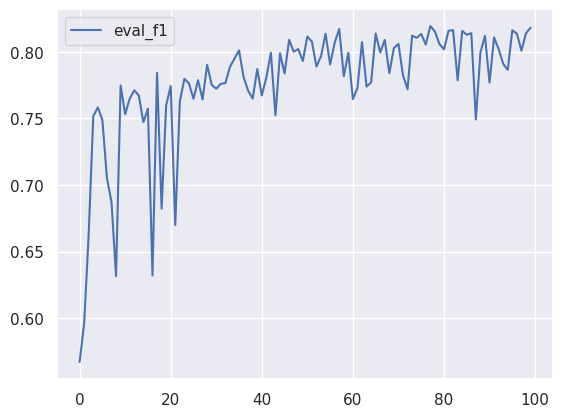

In [ ]:
plt.plot(eval_f1_history_epochs, label='eval_f1')
plt.legend()
plt.show()

Видим, что получается чуть хуже, чем без дропаута. Попробуем увеличить число эпох (по идее с дропаутом может обучаться медленнее, но в итоге быть лучше)

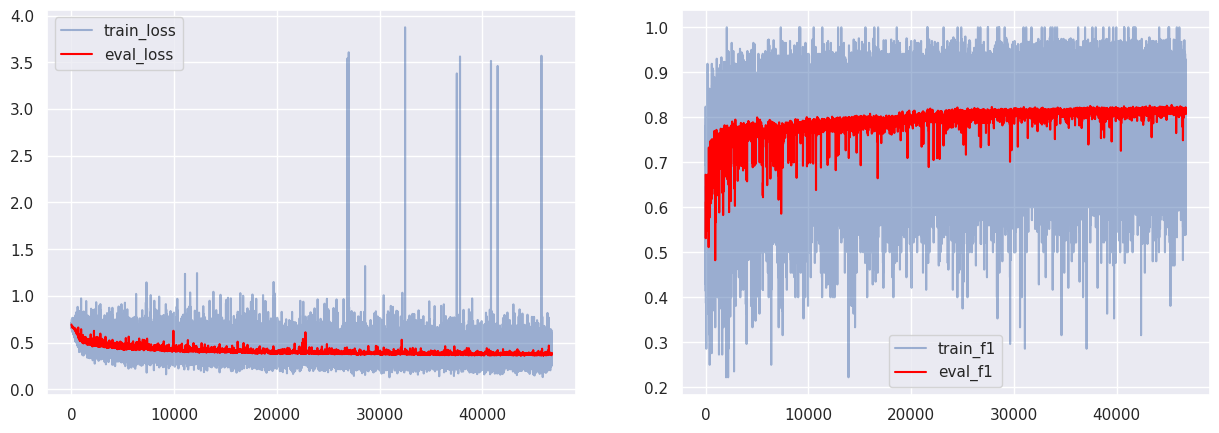

In [ ]:
model = BestTorchModel_Dropout(num_labels=1, input_size=X_train.shape[1], hidden_size=16, p_list=[0.1, 0.1], n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=250)

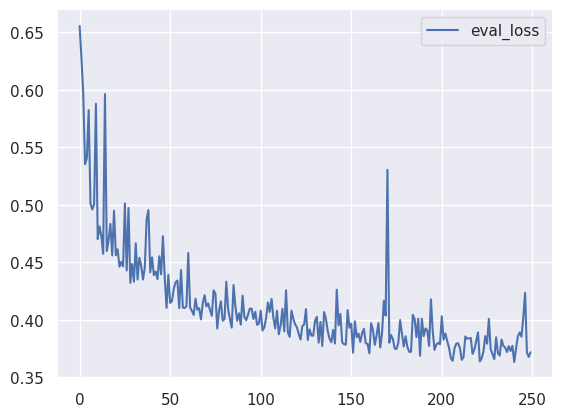

In [ ]:
plt.plot(eval_loss_history_epochs, label='eval_loss')
plt.legend()
plt.show()

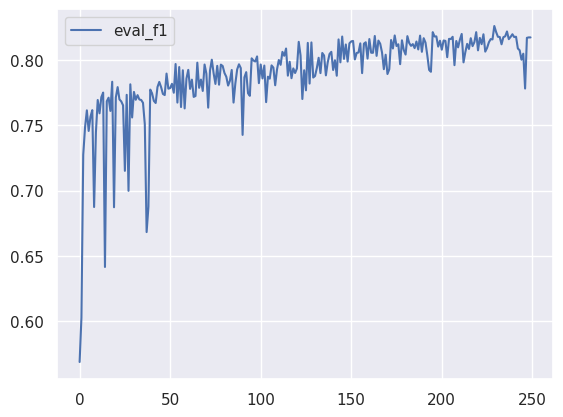

In [ ]:
plt.plot(eval_f1_history_epochs, label='eval_f1')
plt.legend()
plt.show()

По графикам выберем 230 как количество эпох

In [ ]:
best_model = models[230-1]
test_preds = (best_model(torch.Tensor(X_test.values).to(device)) >= 0.5).int().cpu().tolist()
print(classification_report(test_preds, y_test.values.tolist()))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1025
           1       0.79      0.82      0.81       975

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



То есть результаты чуть лучше, чем те, что были. Попробуем увеличить дропаут

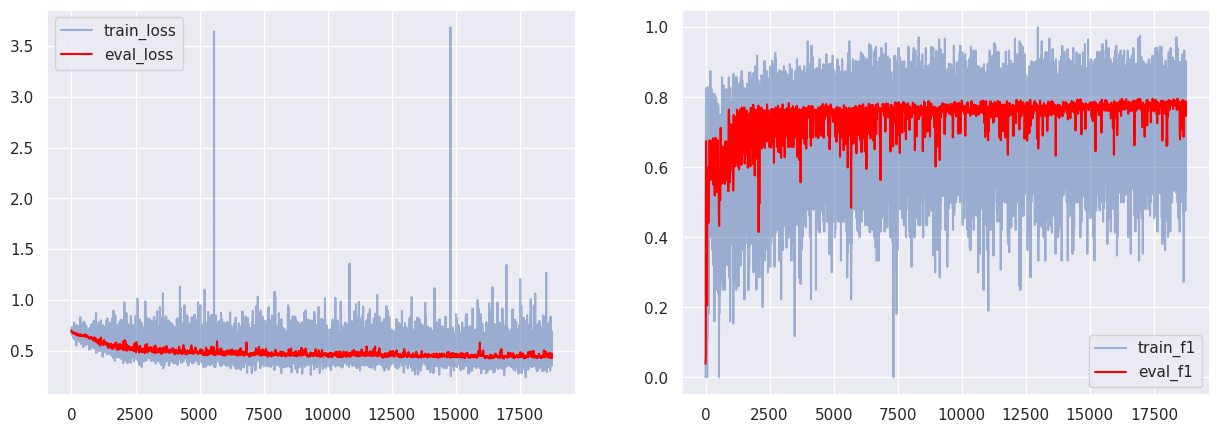

In [ ]:
model = BestTorchModel_Dropout(num_labels=1, input_size=X_train.shape[1], hidden_size=16, p_list=[0.2, 0.5], n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=100)

Получилось хуже. Вернемся к небольшому дропауту. Логично поставить больший дропаут ближе к выходному слою, а в начале меньший (или вообще без дропаута). Это рассказывали нам в лекции.

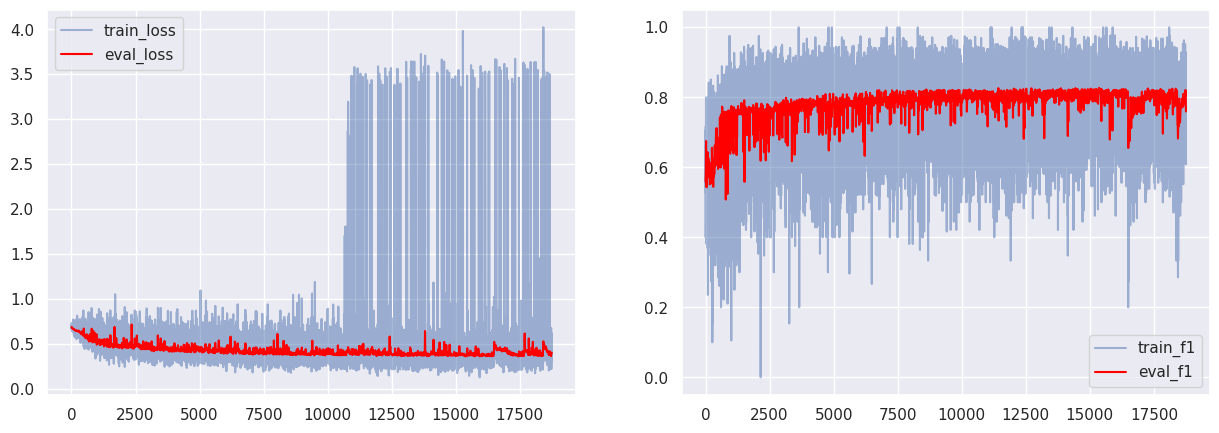

In [ ]:
model = BestTorchModel_Dropout(num_labels=1, input_size=X_train.shape[1], hidden_size=16, p_list=[0, 0.25], n_linear_layers=2)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.75)
models, eval_loss_history_epochs, eval_f1_history_epochs = train_model(model, num_epochs=100)

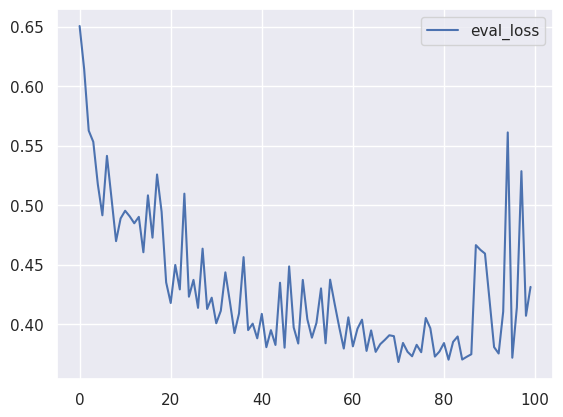

In [ ]:
plt.plot(eval_loss_history_epochs, label='eval_loss')
plt.legend()
plt.show()

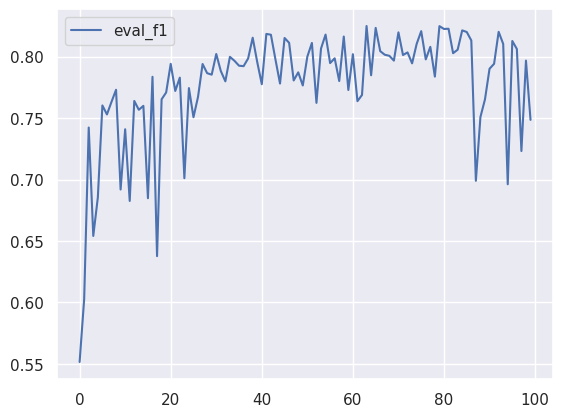

In [ ]:
plt.plot(eval_f1_history_epochs, label='eval_f1')
plt.legend()
plt.show()

По графикам делаем вид, что имеет смысл взять 70 эпох.

In [ ]:
best_model = models[70 - 1]
test_preds = (best_model(torch.Tensor(X_test.values).to(device)) >= 0.5).int().cpu().tolist()
print(classification_report(test_preds, y_test.values.tolist()))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1012
           1       0.80      0.82      0.81       988

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



Тут тоже получили небольшое улучшение по сравнению с моделью без дропаута.